In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
import numpy as np
import pandas as pd



import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

FULL FLOW DATA PIPELINE FOR CREDIT CARD FRAUD DETECTION MODEL
-

Load Data
-
Data Understanding
-
Duplicate Check
-
Missing Value Analysis
-
Distribution Analysis
-
Outlier Analysis
-
EDA
-
Feature Engineering
-
Model Building
-
Model Evaluation
-

DATA LOAD
=

In [902]:
df = pd.read_csv("/kaggle/input/datasets/adityachandra1611/credit-card-fraud-detection-data/CreditCardData.csv")

print(df.shape)
df.head()


(100000, 16)


,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,#3577 209,14-Oct-20,Wednesday,19,Visa,Tap,£5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,#3039 221,14-Oct-20,Wednesday,17,MasterCard,PIN,£288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,#2694 780,14-Oct-20,Wednesday,14,Visa,Tap,£5,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,#2640 960,13-Oct-20,Tuesday,14,Visa,Tap,£28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,#2771 031,13-Oct-20,Tuesday,23,Visa,CVC,£91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


In [903]:
print(df.shape)
df.tail()

(100000, 16)


,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
99995,#3203 892,13-Oct-20,Tuesday,22,MasterCard,Tap,£15,POS,Electronics,United Kingdom,United Kingdom,United Kingdom,F,53.8,Halifax,0
99996,#3304 849,14-Oct-20,Wednesday,23,MasterCard,PIN,£7,ATM,Children,Russia,Russia,Russia,M,45.0,Barclays,0
99997,#3532 129,13-Oct-20,Tuesday,11,MasterCard,PIN,£21,ATM,Subscription,United Kingdom,United Kingdom,United Kingdom,F,46.5,HSBC,0
99998,#3107 092,14-Oct-20,Wednesday,22,Visa,Tap,£25,POS,Products,United Kingdom,United Kingdom,United Kingdom,M,48.2,Barclays,0
99999,#3400 711,14-Oct-20,Wednesday,16,Visa,PIN,£226,POS,Restaurant,United Kingdom,United Kingdom,United Kingdom,M,31.7,Monzo,0


In [556]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Transaction ID          100000 non-null  object 
 1   Date                    100000 non-null  object 
 2   Day of Week             100000 non-null  object 
 3   Time                    100000 non-null  int64  
 4   Type of Card            100000 non-null  object 
 5   Entry Mode              100000 non-null  object 
 6   Amount                  99994 non-null   object 
 7   Type of Transaction     100000 non-null  object 
 8   Merchant Group          99990 non-null   object 
 9   Country of Transaction  100000 non-null  object 
 10  Shipping Address        99995 non-null   object 
 11  Country of Residence    100000 non-null  object 
 12  Gender                  99996 non-null   object 
 13  Age                     100000 non-null  float64
 14  Bank                 

In [904]:
df.isnull().sum()

Transaction ID             0
Date                       0
Day of Week                0
Time                       0
Type of Card               0
Entry Mode                 0
Amount                     6
Type of Transaction        0
Merchant Group            10
Country of Transaction     0
Shipping Address           5
Country of Residence       0
Gender                     4
Age                        0
Bank                       0
Fraud                      0
dtype: int64

In [905]:
print(df.info())

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Transaction ID          100000 non-null  object 
 1   Date                    100000 non-null  object 
 2   Day of Week             100000 non-null  object 
 3   Time                    100000 non-null  int64  
 4   Type of Card            100000 non-null  object 
 5   Entry Mode              100000 non-null  object 
 6   Amount                  99994 non-null   object 
 7   Type of Transaction     100000 non-null  object 
 8   Merchant Group          99990 non-null   object 
 9   Country of Transaction  100000 non-null  object 
 10  Shipping Address        99995 non-null   object 
 11  Country of Residence    100000 non-null  object 
 12  Gender                  99996 non-null   object 
 13  Age                     100000 non-null  float64
 14  Bank                 

DATA UNDERSTANDING 
-

Fraud
0    92805
1     7195
Name: count, dtype: int64


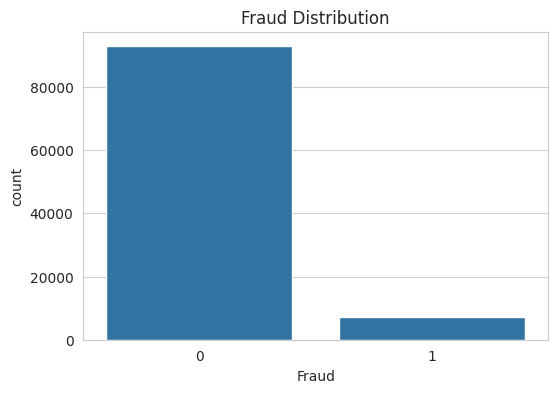

In [906]:
fraud_counts = df['Fraud'].value_counts()

print(fraud_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='Fraud', data=df)

plt.title("Fraud Distribution")
plt.show()

In [907]:
fraud_rate = df['Fraud'].mean()*100

print(f"Fraud Rate: {fraud_rate:.2f}%")

Fraud Rate: 7.20%


In [908]:
fraud_cards = df[df['Fraud'] == 1]

card_fraud_count = fraud_cards['Type of Card'].value_counts()

print(card_fraud_count)

Type of Card
Visa          4320
MasterCard    2875
Name: count, dtype: int64


In [909]:
fraud_df = df[df['Fraud'] == 1]

payment_fraud_count = fraud_df['Entry Mode'].value_counts()

print(payment_fraud_count)

Entry Mode
CVC    3201
PIN    2146
Tap    1848
Name: count, dtype: int64


In [910]:
fraud_txn = df[df['Fraud'] == 1]

txn_fraud_count = fraud_txn['Type of Transaction'].value_counts()

print(txn_fraud_count)

Type of Transaction
Online    3201
POS       2321
ATM       1673
Name: count, dtype: int64


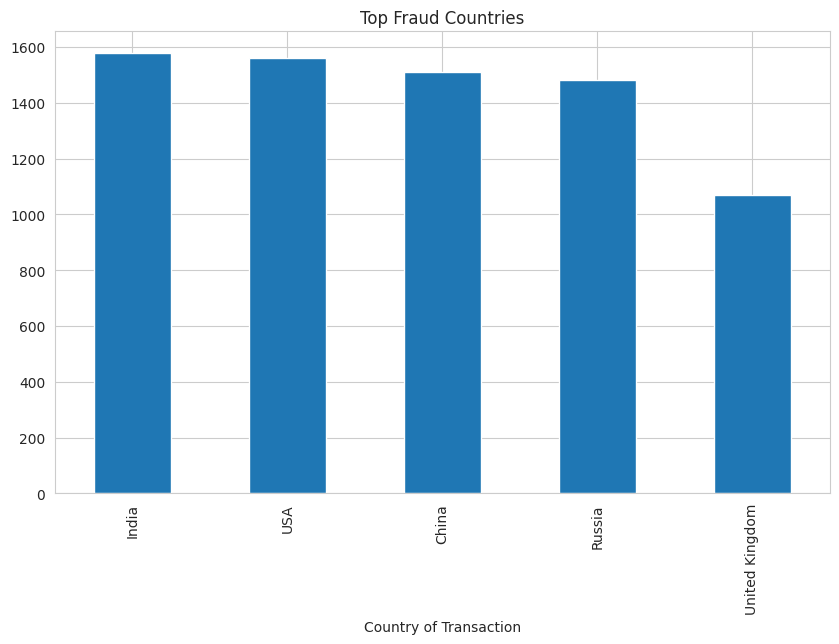

In [911]:
country_fraud = df[df['Fraud']==1][
    'Country of Transaction'
].value_counts()

country_fraud.head(10).plot(
    kind='bar'
)

plt.title("Top Fraud Countries")
plt.show()

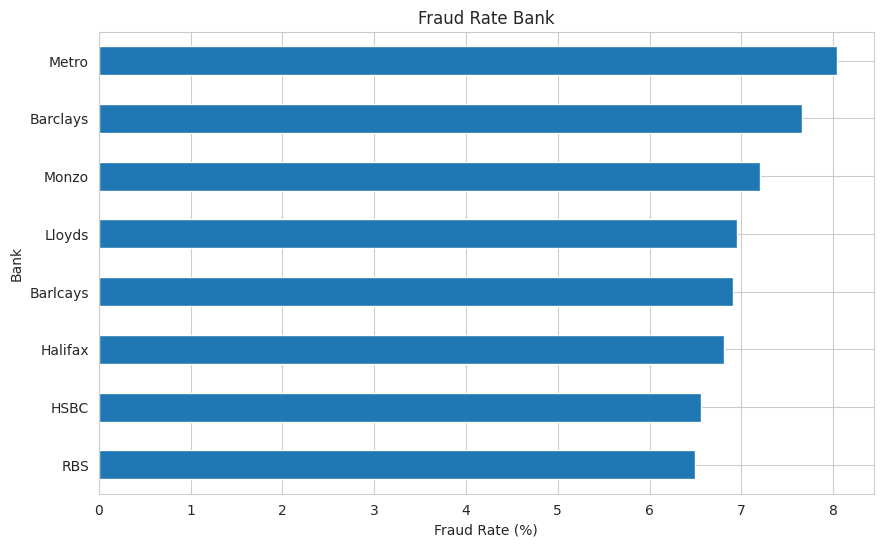

In [758]:
bank_fraud = pd.crosstab(
    df['Bank'],
    df['Fraud'],
    normalize='index'
)*100

bank_fraud[1].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Fraud Rate Bank")
plt.xlabel("Fraud Rate (%)")

plt.show()

In [912]:
summary = pd.DataFrame({

    'Rows':[df.shape[0]],
    'Columns':[df.shape[1]],
    'Missing Values':[df.isnull().sum().sum()],
    'Duplicates':[df.duplicated().sum()],
    'Fraud Rate (%)':[round(df['Fraud'].mean()*100,2)]

})

summary

,Rows,Columns,Missing Values,Duplicates,Fraud Rate (%)
0,100000,16,25,0,7.2


In [913]:
payment_count = df['Day of Week'].value_counts()

print(payment_count)

Day of Week
Wednesday    50177
Tuesday      49797
Friday          14
Thursday        12
Name: count, dtype: int64


In [914]:
max_day = df['Day of Week'].value_counts().idxmax()
max_count = df['Day of Week'].value_counts().max()

print(f"Maximum transactions occurred on {max_day}: {max_count}")

Maximum transactions occurred on Wednesday: 50177


In [915]:
fraud_hour = (
    df[df['Fraud'] == 1]
    .groupby('Time')
    .size()
    .sort_values(ascending=False)
)

print(fraud_hour.head())

Time
2    536
3    531
6    515
0    509
5    489
dtype: int64


In [916]:
time_counts = df['Time'].value_counts().sort_index()

print(time_counts)

Time
0      509
1      484
2      536
3      531
4      474
5      489
6      515
7     5717
8     5683
9     5570
10    5610
11    5748
12    5754
13    5810
14    5686
15    5685
16    5785
17    5665
18    5548
19    5622
20    5522
21    5684
22    5622
23    5750
24       1
Name: count, dtype: int64


In [917]:
card_day = pd.crosstab(
    df['Day of Week'],
    df['Type of Card']
)

print(card_day)

Type of Card  MasterCard   Visa
Day of Week                    
Friday                 4     10
Thursday               6      6
Tuesday            23010  26787
Wednesday          23168  27009


In [918]:
card_entry = pd.crosstab(
    df['Type of Card'],
    df['Entry Mode']
)

print(card_entry)

Entry Mode      CVC    PIN   Tap
Type of Card                    
MasterCard    15625  22958  7605
Visa          17856  27018  8938


In [919]:
day_card_amount = df.groupby(
    ['Day of Week', 'Type of Card']
)['Amount'].sum().reset_index()

print(day_card_amount)

  Day of Week Type of Card                                             Amount
0      Friday   MasterCard                                    £198£13£215£134
1      Friday         Visa                 £171£285£25£26£337£243£37£16£55£21
2    Thursday   MasterCard                              £25£166£28£18£238£288
3    Thursday         Visa                               £24£294£169£243£7£23
4     Tuesday   MasterCard  £30£154£39£21£211£25£25£397£349£153£27£30£123£...
5     Tuesday         Visa  £28£91£231£326£28£22£397£38£9£381£16£29£49£270...
6   Wednesday   MasterCard  £288£17£106£98£29£155£94£5£12£20£285£23£226£12...
7   Wednesday         Visa  £5£5£242£38£12£30£13£11£320£206£57£59£26£24£86...


In [920]:
max_card_day = day_card_amount.loc[
    day_card_amount.groupby('Day of Week')['Amount'].idxmax()
]

print(max_card_day)

  Day of Week Type of Card                                             Amount
0      Friday   MasterCard                                    £198£13£215£134
2    Thursday   MasterCard                              £25£166£28£18£238£288
4     Tuesday   MasterCard  £30£154£39£21£211£25£25£397£349£153£27£30£123£...
7   Wednesday         Visa  £5£5£242£38£12£30£13£11£320£206£57£59£26£24£86...


In [921]:
fraud_df = df[df['Fraud'] == 1]

pd.crosstab(
    fraud_df['Day of Week'],
    fraud_df['Type of Transaction']
)

Type of Transaction,ATM,Online,POS
Day of Week,,,
Friday,0,0,1
Thursday,0,0,2
Tuesday,860,1695,1178
Wednesday,813,1506,1140


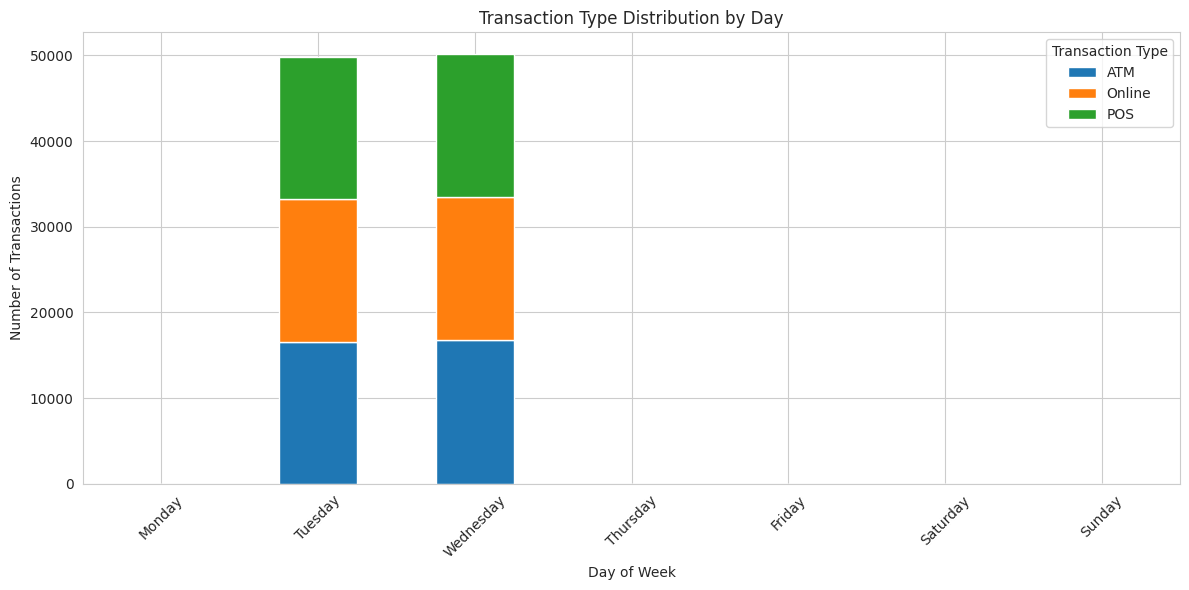

In [922]:
import pandas as pd
import matplotlib.pyplot as plt

# Count transactions by day and transaction type
day_transaction = pd.crosstab(
    df['Day of Week'],
    df['Type of Transaction']
)

# Arrange days in proper order
days_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

day_transaction = day_transaction.reindex(days_order)

# Plot
day_transaction.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Transaction Type Distribution by Day')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')
plt.legend(title='Transaction Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [923]:
merchant_card = pd.crosstab(
    df['Merchant Group'],
    df['Type of Card']
)

print(merchant_card)

Type of Card    MasterCard  Visa
Merchant Group                  
Children              4927  5752
Electronics           4451  5265
Entertainment         4546  5293
Fashion               4683  5304
Food                  4549  5298
Gaming                4637  5374
Products              4524  5315
Restaurant            4637  5441
Services              4590  5427
Subscription          4641  5336


In [924]:
country_card = pd.crosstab(
    df['Country of Transaction'],
    df['Type of Card']
)

print(country_card)

Type of Card            MasterCard   Visa
Country of Transaction                   
China                         3263   3889
India                         3312   3782
Russia                        3419   3838
USA                           3378   3920
United Kingdom               32816  38383


In [925]:
country_card = pd.crosstab(
    df['Country of Transaction'],
    df['Type of Card']
)

result = pd.DataFrame({
    'Most Used Card': country_card.idxmax(axis=1),
    'Transactions': country_card.max(axis=1)
})

print(result.sort_values('Transactions', ascending=False))

                       Most Used Card  Transactions
Country of Transaction                             
United Kingdom                   Visa         38383
USA                              Visa          3920
China                            Visa          3889
Russia                           Visa          3838
India                            Visa          3782


In [926]:
country_mode = pd.crosstab(
    df['Country of Transaction'],
    df['Entry Mode']
)

print(country_mode)

Entry Mode                CVC    PIN    Tap
Country of Transaction                     
China                    2356   3595   1201
India                    2410   3524   1160
Russia                   2360   3620   1277
USA                      2429   3664   1205
United Kingdom          23926  35573  11700


In [774]:
result = pd.DataFrame({
    'Most Used Entry Mode': country_mode.idxmax(axis=1),
    'Transactions': country_mode.max(axis=1)
})

print(result.sort_values('Transactions', ascending=False))

                       Most Used Entry Mode  Transactions
Country of Transaction                                   
United Kingdom                          PIN         35573
USA                                     PIN          3664
Russia                                  PIN          3620
China                                   PIN          3595
India                                   PIN          3524


In [927]:
gender_card = pd.crosstab(
    df['Gender'],
    df['Type of Card']
)

print(gender_card)

Type of Card  MasterCard   Visa
Gender                         
F                  22684  26437
M                  23502  27373


In [928]:
result = pd.DataFrame({
    'Most Used Card': gender_card.idxmax(axis=1),
    'Count': gender_card.max(axis=1)
})

print(result)

       Most Used Card  Count
Gender                      
F                Visa  26437
M                Visa  27373


In [929]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0,18,25,35,45,55,65,100],
    labels=[
        '0-18',
        '19-25',
        '26-35',
        '36-45',
        '46-55',
        '56-65',
        '65+'
    ]
)

print(df['Age Group'].value_counts())

Age Group
36-45    34452
46-55    33847
26-35    13754
56-65    13467
65+       2250
19-25     2046
0-18       184
Name: count, dtype: int64


In [778]:
fraud_bank = (
    df[df['Fraud']==1]
    .groupby('Bank')
    .size()
    .sort_values(ascending=False)
)

print(fraud_bank)

Bank
Barclays    2294
Metro        805
Monzo        728
Lloyds       693
Barlcays     690
Halifax      680
HSBC         653
RBS          652
dtype: int64


In [930]:
age_bank = pd.crosstab(
    df['Age Group'],
    df['Bank']
)

print(age_bank)

Bank       Barclays  Barlcays  HSBC  Halifax  Lloyds  Metro  Monzo   RBS
Age Group                                                               
0-18             49        23    17       18      29     10     20    18
19-25           582       202   229      221     225    173    204   210
26-35          4074      1355  1302     1338    1412   1373   1431  1469
36-45         10406      3537  3417     3451    3409   3428   3363  3441
46-55         10161      3334  3389     3397    3344   3389   3486  3347
56-65          3989      1326  1372     1321    1313   1410   1388  1348
65+             675       216   231      242     233    229    211   213


In [931]:
result = pd.DataFrame({
    'Most Used Bank': age_bank.idxmax(axis=1),
    'Count': age_bank.max(axis=1)
})

print(result)

          Most Used Bank  Count
Age Group                      
0-18            Barclays     49
19-25           Barclays    582
26-35           Barclays   4074
36-45           Barclays  10406
46-55           Barclays  10161
56-65           Barclays   3989
65+             Barclays    675


In [932]:
fraud_date_card = pd.crosstab(
    [df[df['Fraud']==1]['Date']],
    df[df['Fraud']==1]['Type of Card']
)

print(fraud_date_card)

Type of Card  MasterCard  Visa
Date                          
13-Oct-20           1485  2249
14-Oct-20           1390  2069
15-Oct-20              0     1
16-Oct-20              0     1


In [933]:
date_card = pd.crosstab(
    df['Date'],
    df['Type of Card']
)

print(date_card.head())

Type of Card  MasterCard   Visa
Date                           
13-Oct-20          23017  26797
14-Oct-20          23171  27013
15-Oct-20              0      1
16-Oct-20              0      1


In [934]:
date_card_mode = pd.crosstab(
    [df['Date'], df['Type of Card']],
    df['Entry Mode']
)

print(date_card_mode.head(20))

Entry Mode               CVC    PIN   Tap
Date      Type of Card                   
13-Oct-20 MasterCard    7791  11477  3749
          Visa          8952  13349  4496
14-Oct-20 MasterCard    7834  11481  3856
          Visa          8904  13667  4442
15-Oct-20 Visa             0      1     0
16-Oct-20 Visa             0      1     0


In [935]:
day_date_time = (
    df.groupby(
        ['Day of Week', 'Date', 'Time']
    )
    .size()
    .reset_index(name='Transactions')
)

print(day_date_time.head())

  Day of Week       Date  Time  Transactions
0      Friday  13-Oct-20     7             1
1      Friday  13-Oct-20     9             1
2      Friday  13-Oct-20    10             1
3      Friday  13-Oct-20    11             1
4      Friday  13-Oct-20    12             2


In [936]:
pivot = pd.pivot_table(
    df,
    index='Day of Week',
    columns='Time',
    aggfunc='size',
    fill_value=0
)

print(pivot)

Time          0    1    2    3    4    5    6     7     8     9   ...    15  \
Day of Week                                                       ...         
Friday         0    0    0    0    0    0    0     1     1     1  ...     1   
Thursday       0    0    0    0    0    0    0     2     1     2  ...     0   
Tuesday      262  257  283  272  245  266  276  2792  2786  2720  ...  2832   
Wednesday    247  227  253  259  229  223  239  2922  2895  2847  ...  2852   

Time           16    17    18    19    20    21    22    23  24  
Day of Week                                                      
Friday          1     0     0     1     0     0     0     0   0  
Thursday        2     0     1     1     0     0     0     0   0  
Tuesday      2880  2779  2780  2823  2816  2865  2811  2876   0  
Wednesday    2902  2886  2767  2797  2706  2819  2811  2874   1  

[4 rows x 25 columns]


In [937]:
pd.crosstab(
    df['Day of Week'],
    df['Type of Card']
)

Type of Card,MasterCard,Visa
Day of Week,,
Friday,4,10
Thursday,6,6
Tuesday,23010,26787
Wednesday,23168,27009


In [938]:
pivot = pd.crosstab(
    df['Day of Week'],
    df['Time']
)

result = pd.DataFrame({
    'Peak Hour': pivot.idxmax(axis=1),
    'Transactions': pivot.max(axis=1)
})

print(result)

             Peak Hour  Transactions
Day of Week                         
Friday              11             3
Thursday             7             2
Tuesday             16          2880
Wednesday           13          2937


In [939]:
df[df['Type of Card']=='MasterCard']\
.groupby('Day of Week').size()

Day of Week
Friday           4
Thursday         6
Tuesday      23010
Wednesday    23168
dtype: int64

In [940]:
df[df['Type of Card']=='Visa']\
.groupby('Day of Week').size()

Day of Week
Friday          10
Thursday         6
Tuesday      26787
Wednesday    27009
dtype: int64

In [941]:
df[df['Type of Card'] == 'Visa']\
.groupby('Day of Week').size()

Day of Week
Friday          10
Thursday         6
Tuesday      26787
Wednesday    27009
dtype: int64

3.Most Fraudlent Payment Mode

In [942]:
entry_fraud = pd.crosstab(
    df['Entry Mode'],
    df['Fraud'],
    normalize='index'
) * 100

entry_fraud.columns = ['Non Fraud %', 'Fraud %']

print(entry_fraud)

print("\nMost Fraudulent Entry Mode:")
print(entry_fraud['Fraud %'].idxmax())

            Non Fraud %    Fraud %
Entry Mode                        
CVC           90.439354   9.560646
PIN           95.705939   4.294061
Tap           88.829112  11.170888

Most Fraudulent Entry Mode:
Tap


In [943]:
txn_fraud = pd.crosstab(
    df['Type of Transaction'],
    df['Fraud'],
    normalize='index'
) * 100

txn_fraud.columns = ['Non Fraud %', 'Fraud %']

print(txn_fraud)

print("\nMost Fraudulent Transaction Type:")
print(txn_fraud['Fraud %'].idxmax())

                     Non Fraud %   Fraud %
Type of Transaction                       
ATM                    94.972050  5.027950
Online                 90.439354  9.560646
POS                    93.018499  6.981501

Most Fraudulent Transaction Type:
Online


In [944]:
merchant_fraud = pd.crosstab(
    df['Merchant Group'],
    df['Fraud'],
    normalize='index'
) * 100

merchant_fraud.columns = ['Non Fraud %', 'Fraud %']

print(
    merchant_fraud.sort_values(
        'Fraud %',
        ascending=False
    )
)

print("\nMost Risky Merchant:")
print(merchant_fraud['Fraud %'].idxmax())

                Non Fraud %    Fraud %
Merchant Group                        
Children          88.013859  11.986141
Electronics       89.872375  10.127625
Fashion           90.747972   9.252028
Entertainment     94.003456   5.996544
Services          94.080064   5.919936
Food              94.130192   5.869808
Gaming            94.176406   5.823594
Products          94.277874   5.722126
Subscription      94.387090   5.612910
Restaurant        94.641794   5.358206

Most Risky Merchant:
Children


In [945]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0,18,25,35,45,55,65,100],
    labels=[
        '0-18',
        '19-25',
        '26-35',
        '36-45',
        '46-55',
        '56-65',
        '65+'
    ]
)

age_fraud = pd.crosstab(
    df['Age Group'],
    df['Fraud'],
    normalize='index'
) * 100

age_fraud.columns = ['Non Fraud %', 'Fraud %']

print(age_fraud)

print("\nMost Risky Age Group:")
print(age_fraud['Fraud %'].idxmax())

           Non Fraud %   Fraud %
Age Group                       
0-18         92.934783  7.065217
19-25        92.570870  7.429130
26-35        92.860259  7.139741
36-45        92.769651  7.230349
46-55        92.811771  7.188229
56-65        92.812059  7.187941
65+          93.066667  6.933333

Most Risky Age Group:
19-25


10. Most Risky Bank+ Card + Payment Mode

In [946]:
total_transactions = len(df)

fraud_transactions = df['Fraud'].sum()

genuine_transactions = (
    total_transactions
    - fraud_transactions
)

fraud_rate = (
    fraud_transactions
    / total_transactions
) * 100

print("="*40)

print(
    f"Total Transactions: {total_transactions:,}"
)

print(
    f"Fraudulent Transactions: {fraud_transactions:,}"
)

print(
    f"Genuine Transactions: {genuine_transactions:,}"
)

print(
    f"Fraud Rate: {fraud_rate:.2f}%"
)

print("="*40)

Total Transactions: 100,000
Fraudulent Transactions: 7,195
Genuine Transactions: 92,805
Fraud Rate: 7.20%


In [947]:
peak_day = df['Day of Week'].value_counts().idxmax()

peak_hour = df['Time'].value_counts().idxmax()

risky_day_hour = (
    pd.crosstab(
        [df['Day of Week'], df['Time']],
        df['Fraud'],
        normalize='index'
    ) * 100
)

risky_day_hour.columns = [
    'Non Fraud %',
    'Fraud %'
]

risky_combination = (
    risky_day_hour['Fraud %']
    .idxmax()
)

print("="*50)

print("Peak Transaction Day:", peak_day)

print("Peak Transaction Hour:", peak_hour)

print(
    "Most Risky Day-Hour Combination:",
    risky_combination
)

print("="*50)

Peak Transaction Day: Wednesday
Peak Transaction Hour: 13
Most Risky Day-Hour Combination: ('Friday', np.int64(8))


In [948]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0,18,25,35,45,55,65,100]
)

In [950]:
bank_card_payment_fraud = pd.crosstab(
    [
        df['Bank'],
        df['Type of Card'],
        df['Entry Mode']
    ],
    df['Fraud'],
    normalize='index'
) * 100

bank_card_payment_fraud.columns = [
    'Non Fraud %',
    'Fraud %'
]

print(
    bank_card_payment_fraud
    .sort_values(
        'Fraud %',
        ascending=False
    )
    .head(20)
)

most_fraudulent_bank_combo = (
    bank_card_payment_fraud['Fraud %']
    .idxmax()
)

print(
    "\nMost Fraudulent Bank-Card-Payment Combination:"
)

print(most_fraudulent_bank_combo)

                                  Non Fraud %    Fraud %
Bank     Type of Card Entry Mode                        
Lloyds   Visa         Tap           85.147392  14.852608
Metro    Visa         Tap           86.373874  13.626126
Halifax  Visa         Tap           86.971429  13.028571
Metro    MasterCard   Tap           87.397260  12.602740
Barclays Visa         Tap           87.980769  12.019231
HSBC     Visa         Tap           88.100686  11.899314
Monzo    Visa         Tap           88.260406  11.739594
RBS      Visa         Tap           88.495575  11.504425
Barlcays Visa         Tap           88.672769  11.327231
Metro    Visa         CVC           88.813174  11.186826
Barclays Visa         CVC           89.138925  10.861075
HSBC     MasterCard   Tap           89.445910  10.554090
Barlcays Visa         CVC           89.637599  10.362401
Monzo    Visa         CVC           89.797069  10.202931
Barclays MasterCard   Tap           90.142730   9.857270
RBS      Visa         CVC      

In [951]:
df = df.drop('Date', axis=1)

In [952]:
features = [
    'Age',
    'Gender',
    'Bank',
    'Merchant Group',
    'Country of Transaction',
    'Type of Card',
    'Entry Mode',
    'Type of Transaction',
    'Amount',
    'Day of Week',
    'Time'
]

print(df[features].head())

    Age Gender      Bank Merchant Group Country of Transaction Type of Card  \
0  25.2      M       RBS  Entertainment         United Kingdom         Visa   
1  49.6      F    Lloyds       Services                    USA   MasterCard   
2  42.2      F  Barclays     Restaurant                  India         Visa   
3  51.0      F  Barclays  Entertainment         United Kingdom         Visa   
4  38.0      M   Halifax    Electronics                    USA         Visa   

  Entry Mode Type of Transaction Amount Day of Week  Time  
0        Tap                 POS     £5   Wednesday    19  
1        PIN                 POS   £288   Wednesday    17  
2        Tap                 POS     £5   Wednesday    14  
3        Tap                 POS    £28     Tuesday    14  
4        CVC              Online    £91     Tuesday    23  


 DUPLICATE ROWS/COLUMNS AND MISSING VALUE ANALYSIS
 -

In [953]:
print(df[features].isnull().sum())

Age                        0
Gender                     4
Bank                       0
Merchant Group            10
Country of Transaction     0
Type of Card               0
Entry Mode                 0
Type of Transaction        0
Amount                     6
Day of Week                0
Time                       0
dtype: int64


In [954]:
missing_df = (
    df.isnull()
      .sum()
      .reset_index()
)

missing_df.columns = [
    'Column',
    'Missing Values'
]

missing_df['Percentage'] = (
    missing_df['Missing Values']
    / len(df)
    * 100
).round(2)

missing_df = missing_df[
    missing_df['Missing Values'] > 0
].sort_values(
    'Missing Values',
    ascending=False
)

missing_df

,Column,Missing Values,Percentage
7,Merchant Group,10,0.01
5,Amount,6,0.01
9,Shipping Address,5,0.00
11,Gender,4,0.00


NEGLECTING MISSING VALUE BECAUSE PERCENTAGE IS LOW

In [955]:
df['Merchant Group'] = df['Merchant Group'].fillna(
    'Unknown'
)

In [956]:
df['Amount'] = df['Amount'].fillna(
    'Unknown'
)

In [957]:
df['Shipping Address'] = df['Shipping Address'].fillna(
    'Unknown'
)

In [958]:
df['Gender'] = df['Gender'].fillna(
    'Unknown'
)

In [959]:
df = df.drop_duplicates()

In [960]:
print(df[df.duplicated()])

Empty DataFrame
Columns: [Transaction ID, Day of Week, Time, Type of Card, Entry Mode, Amount, Type of Transaction, Merchant Group, Country of Transaction, Shipping Address, Country of Residence, Gender, Age, Bank, Fraud, Age Group]
Index: []


DISTRIBUTION ANALYSIS
-

UNDESTANDS HOW NUMERICAL FEATURES ARE DISTRIBUTED 
-
CHECK SKEWNESS, 
CHECK NORMALITY

In [961]:
import pandas as pd
import numpy as np

# Basic shape
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# Missing values
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (100000, 16)

Columns:
['Transaction ID', 'Day of Week', 'Time', 'Type of Card', 'Entry Mode', 'Amount', 'Type of Transaction', 'Merchant Group', 'Country of Transaction', 'Shipping Address', 'Country of Residence', 'Gender', 'Age', 'Bank', 'Fraud', 'Age Group']

Data types:
Transaction ID              object
Day of Week                 object
Time                         int64
Type of Card                object
Entry Mode                  object
Amount                      object
Type of Transaction         object
Merchant Group              object
Country of Transaction      object
Shipping Address            object
Country of Residence        object
Gender                      object
Age                        float64
Bank                        object
Fraud                        int64
Age Group                 category
dtype: object

Missing values:
Transaction ID            0
Day of Week               0
Time                      0
Type of Card              0
Entry Mode    

In [962]:
df['Amount'] = (
    df['Amount']
    .astype(str)
    .str.replace('£', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['Amount'] = pd.to_numeric(
    df['Amount'],
    errors='coerce'
)

In [963]:
print(df['Amount'].dtype)

float64


In [964]:
df['Time'] = pd.to_numeric(
    df['Time'],
    errors='coerce'
)

df['Time'] = df['Time'].astype('Int64')

In [965]:
print(df['Time'].dtype)

Int64


In [966]:
df['Age Group'] = df['Age Group'].astype(str)

In [967]:
print(df['Age Group'].dtype)

object


In [968]:
import pandas as pd
import numpy as np

# Basic shape
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# Missing values
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (100000, 16)

Columns:
['Transaction ID', 'Day of Week', 'Time', 'Type of Card', 'Entry Mode', 'Amount', 'Type of Transaction', 'Merchant Group', 'Country of Transaction', 'Shipping Address', 'Country of Residence', 'Gender', 'Age', 'Bank', 'Fraud', 'Age Group']

Data types:
Transaction ID             object
Day of Week                object
Time                        Int64
Type of Card               object
Entry Mode                 object
Amount                    float64
Type of Transaction        object
Merchant Group             object
Country of Transaction     object
Shipping Address           object
Country of Residence       object
Gender                     object
Age                       float64
Bank                       object
Fraud                       int64
Age Group                  object
dtype: object

Missing values:
Amount                    6
Transaction ID            0
Time                      0
Day of Week               0
Type of Card              0
En

In [969]:
df['Amount'] = df['Amount'].fillna(
    df['Amount'].median()
)

In [970]:
print(df['Amount'].isnull().sum())

0


IDENTIFY NUMERICAL COLUMNS
-

In [971]:
num_cols = df.select_dtypes(
    include=['int64','float64']
).columns

print(num_cols)

Index(['Time', 'Amount', 'Age', 'Fraud'], dtype='object')


HISTOGRAM AND KDE
-

In [972]:
num_cols = [
    col for col in num_cols
    if col != 'Fraud'
]

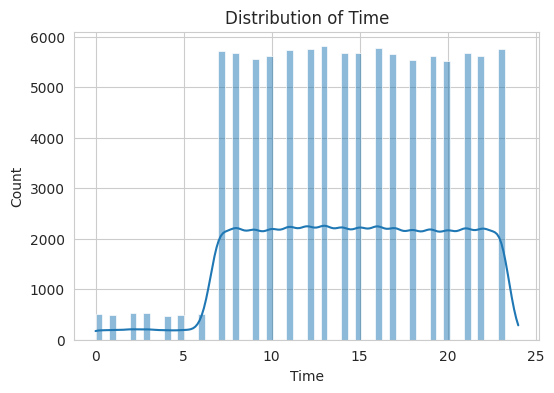

Time: Skewness=-0.196


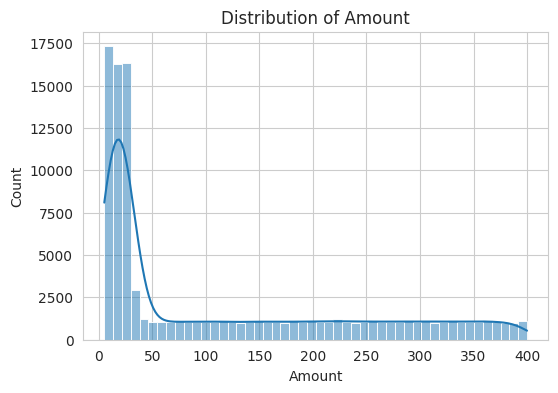

Amount: Skewness=0.929


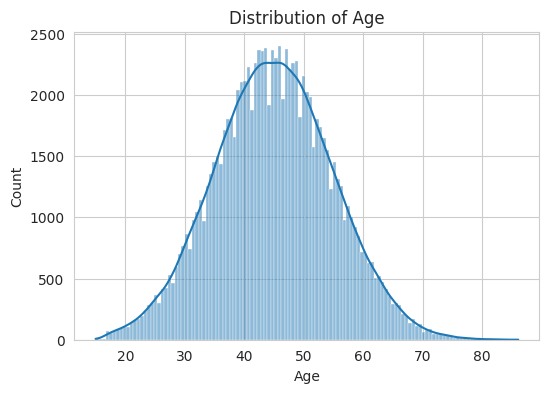

Age: Skewness=0.045


In [973]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f'Distribution of {col}')

    plt.show()

    print(
        f"{col}: Skewness={df[col].skew():.3f}"
    )

SKEWNESS ANALYSIS
-

In [974]:
for col in num_cols:

    skew = df[col].skew()

    if -0.5 <= skew <= 0.5:
        dist = "Approximately Normal"

    elif skew > 0.5:
        dist = "Right Skewed"

    else:
        dist = "Left Skewed"

    print(
        f"{col}: Skewness={skew:.3f} → {dist}"
    )

Time: Skewness=-0.196 → Approximately Normal
Amount: Skewness=0.929 → Right Skewed
Age: Skewness=0.045 → Approximately Normal


FRAUD IS TARGERTING COLUMN- NO NEED OF CONSIDERATION
-

CORRELATION HEATMAP
-

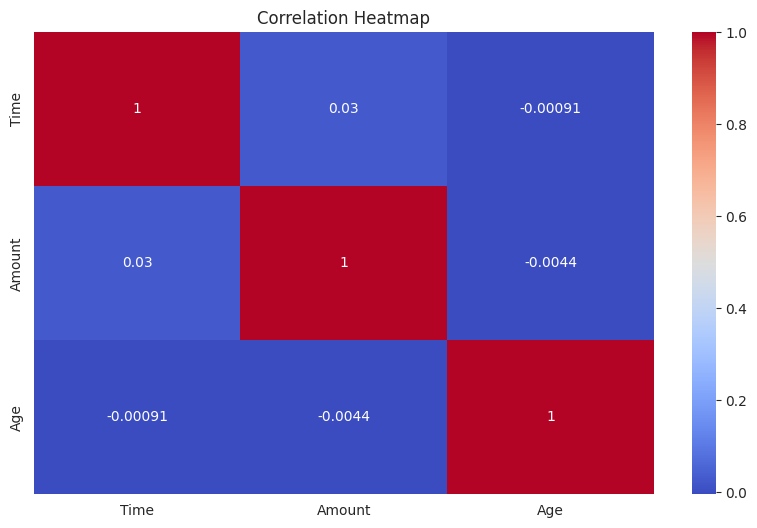

In [975]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Heatmap'
)

plt.show()

OUTLIER ANALYSIS
-
IDENTIFY EXTREME VALUES
-
UNDERSTAND RISK EXPOSURE
-

In [976]:
num_cols = [
    col for col in num_cols
    if col != 'Fraud'
]

BOXPLOT
-

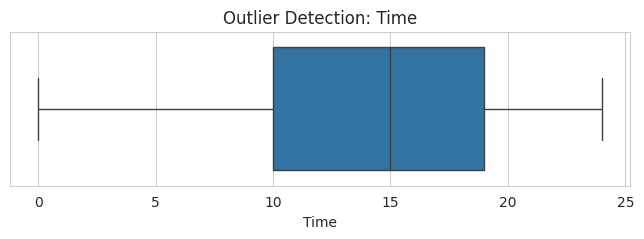

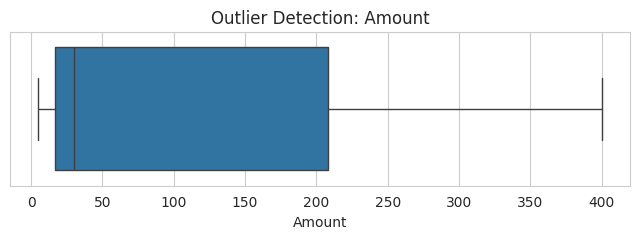

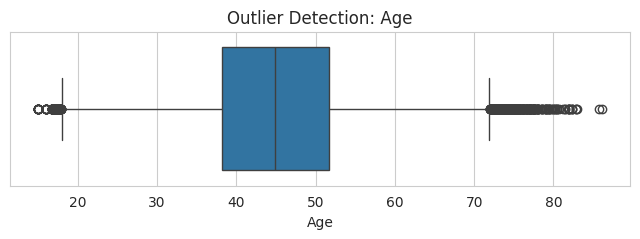

In [977]:
for col in num_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(
       f'Outlier Detection: {col}'
   )

    plt.show()

IQR METHOD

In [978]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[
        (df[col] < lower)
        |
        (df[col] > upper)
    ]

    print(
        f"{col}: {len(outliers)} outliers"
    )

Time: 0 outliers
Amount: 0 outliers
Age: 510 outliers


In [979]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

age_outliers = df[
    (df['Age'] < lower) |
    (df['Age'] > upper)
]

print(age_outliers['Age'].describe())

count    510.000000
mean      56.605686
std       27.117320
min       15.000000
25%       17.600000
50%       73.100000
75%       75.075000
max       86.100000
Name: Age, dtype: float64


In [980]:
print(
    sorted(age_outliers['Age'].unique())
)

[np.float64(15.0), np.float64(16.0), np.float64(16.7), np.float64(16.8), np.float64(16.9), np.float64(17.0), np.float64(17.1), np.float64(17.2), np.float64(17.3), np.float64(17.4), np.float64(17.5), np.float64(17.6), np.float64(17.7), np.float64(17.8), np.float64(17.9), np.float64(72.0), np.float64(72.1), np.float64(72.2), np.float64(72.3), np.float64(72.4), np.float64(72.5), np.float64(72.6), np.float64(72.7), np.float64(72.8), np.float64(72.9), np.float64(73.0), np.float64(73.1), np.float64(73.2), np.float64(73.3), np.float64(73.4), np.float64(73.5), np.float64(73.6), np.float64(73.7), np.float64(73.8), np.float64(73.9), np.float64(74.0), np.float64(74.1), np.float64(74.2), np.float64(74.3), np.float64(74.4), np.float64(74.5), np.float64(74.6), np.float64(74.7), np.float64(74.8), np.float64(74.9), np.float64(75.0), np.float64(75.1), np.float64(75.2), np.float64(75.3), np.float64(75.4), np.float64(75.5), np.float64(75.6), np.float64(75.7), np.float64(75.8), np.float64(75.9), np.float6

In [981]:
print(
    age_outliers['Age']
    .sort_values()
    .unique()
)

[15.  16.  16.7 16.8 16.9 17.  17.1 17.2 17.3 17.4 17.5 17.6 17.7 17.8
 17.9 72.  72.1 72.2 72.3 72.4 72.5 72.6 72.7 72.8 72.9 73.  73.1 73.2
 73.3 73.4 73.5 73.6 73.7 73.8 73.9 74.  74.1 74.2 74.3 74.4 74.5 74.6
 74.7 74.8 74.9 75.  75.1 75.2 75.3 75.4 75.5 75.6 75.7 75.8 75.9 76.
 76.1 76.2 76.3 76.4 76.5 76.6 76.7 76.8 76.9 77.  77.1 77.2 77.3 77.4
 77.5 77.6 77.7 77.9 78.  78.1 78.4 78.5 78.8 79.  79.1 79.3 79.4 79.5
 79.7 79.8 80.  80.1 80.2 80.4 80.5 80.7 81.2 81.4 81.5 81.8 81.9 82.
 82.3 82.4 82.8 82.9 83.  85.7 86.1]


In [982]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outlier_pct = (
        (
            (df[col] < lower)
            |
            (df[col] > upper)
        ).mean()
    )*100

    print(
        f"{col}: {outlier_pct:.2f}%"
    )

Time: 0.00%
Amount: 0.00%
Age: 0.51%


In [983]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df['Age'] = df['Age'].clip(
    lower,
    upper
)

In [984]:
print(
    age_outliers['Age']
    .sort_values()
    .unique()
)

[15.  16.  16.7 16.8 16.9 17.  17.1 17.2 17.3 17.4 17.5 17.6 17.7 17.8
 17.9 72.  72.1 72.2 72.3 72.4 72.5 72.6 72.7 72.8 72.9 73.  73.1 73.2
 73.3 73.4 73.5 73.6 73.7 73.8 73.9 74.  74.1 74.2 74.3 74.4 74.5 74.6
 74.7 74.8 74.9 75.  75.1 75.2 75.3 75.4 75.5 75.6 75.7 75.8 75.9 76.
 76.1 76.2 76.3 76.4 76.5 76.6 76.7 76.8 76.9 77.  77.1 77.2 77.3 77.4
 77.5 77.6 77.7 77.9 78.  78.1 78.4 78.5 78.8 79.  79.1 79.3 79.4 79.5
 79.7 79.8 80.  80.1 80.2 80.4 80.5 80.7 81.2 81.4 81.5 81.8 81.9 82.
 82.3 82.4 82.8 82.9 83.  85.7 86.1]


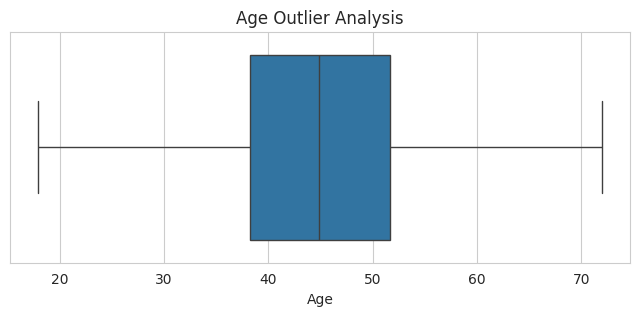

In [985]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))

sns.boxplot(
    x=df['Age']
)

plt.title(
    'Age Outlier Analysis'
)

plt.show()

In [986]:
age_pct = (
    len(age_outliers)
    /
    len(df)
)*100

print(
    f"Age Outlier %: {age_pct:.2f}%"
)

Age Outlier %: 0.51%


In [987]:
age_pct = (
    len(age_outliers)
    /
    len(df)
)*100

print(
    f"Age Outlier %: {age_pct:.2f}%"
)

Age Outlier %: 0.51%


In [988]:
print(
    sorted(age_outliers['Age'].unique())
)

[np.float64(15.0), np.float64(16.0), np.float64(16.7), np.float64(16.8), np.float64(16.9), np.float64(17.0), np.float64(17.1), np.float64(17.2), np.float64(17.3), np.float64(17.4), np.float64(17.5), np.float64(17.6), np.float64(17.7), np.float64(17.8), np.float64(17.9), np.float64(72.0), np.float64(72.1), np.float64(72.2), np.float64(72.3), np.float64(72.4), np.float64(72.5), np.float64(72.6), np.float64(72.7), np.float64(72.8), np.float64(72.9), np.float64(73.0), np.float64(73.1), np.float64(73.2), np.float64(73.3), np.float64(73.4), np.float64(73.5), np.float64(73.6), np.float64(73.7), np.float64(73.8), np.float64(73.9), np.float64(74.0), np.float64(74.1), np.float64(74.2), np.float64(74.3), np.float64(74.4), np.float64(74.5), np.float64(74.6), np.float64(74.7), np.float64(74.8), np.float64(74.9), np.float64(75.0), np.float64(75.1), np.float64(75.2), np.float64(75.3), np.float64(75.4), np.float64(75.5), np.float64(75.6), np.float64(75.7), np.float64(75.8), np.float64(75.9), np.float6

THE PERCENTAGE OF OUTLIER IS LOW, SO WE CAN PROCEED
-

EDA(BUSINESS ANALYSIS)
-

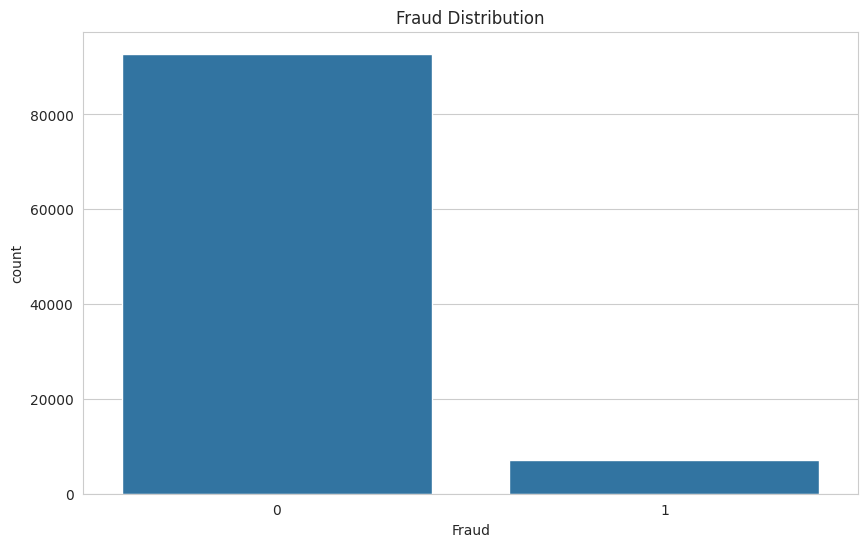

In [989]:
sns.countplot(
    x='Fraud',
    data=df
)

plt.title(
    'Fraud Distribution'
)

plt.show()

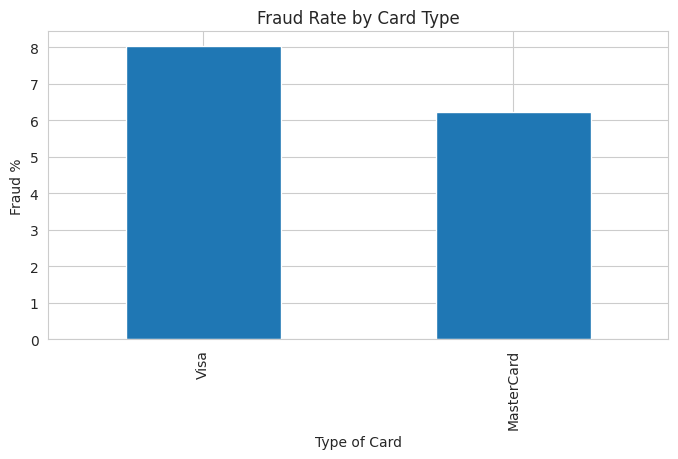

In [990]:
card_fraud = pd.crosstab(
    df['Type of Card'],
    df['Fraud'],
    normalize='index'
)*100

card_fraud[1]\
.sort_values(ascending=False)\
.plot(
    kind='bar',
    figsize=(8,4)
)

plt.ylabel('Fraud %')

plt.title(
    'Fraud Rate by Card Type'
)

plt.show()

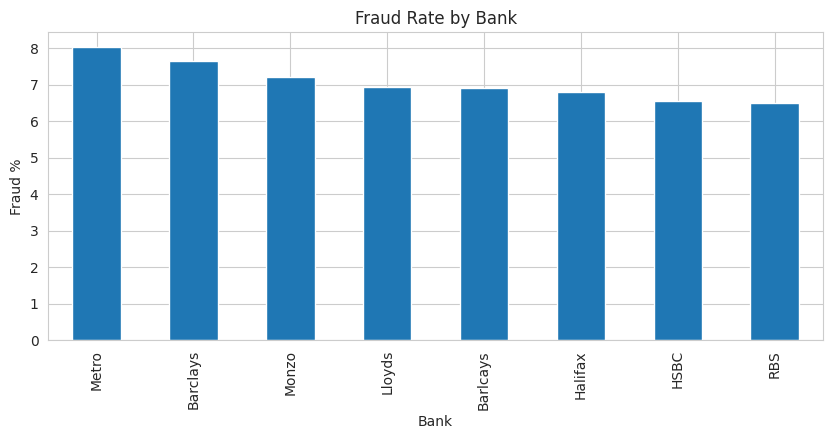

In [991]:
bank_fraud = pd.crosstab(
    df['Bank'],
    df['Fraud'],
    normalize='index'
)*100

bank_fraud[1]\
.sort_values(ascending=False)\
.plot(
    kind='bar',
    figsize=(10,4)
)

plt.ylabel('Fraud %')

plt.title(
    'Fraud Rate by Bank'
)

plt.show()

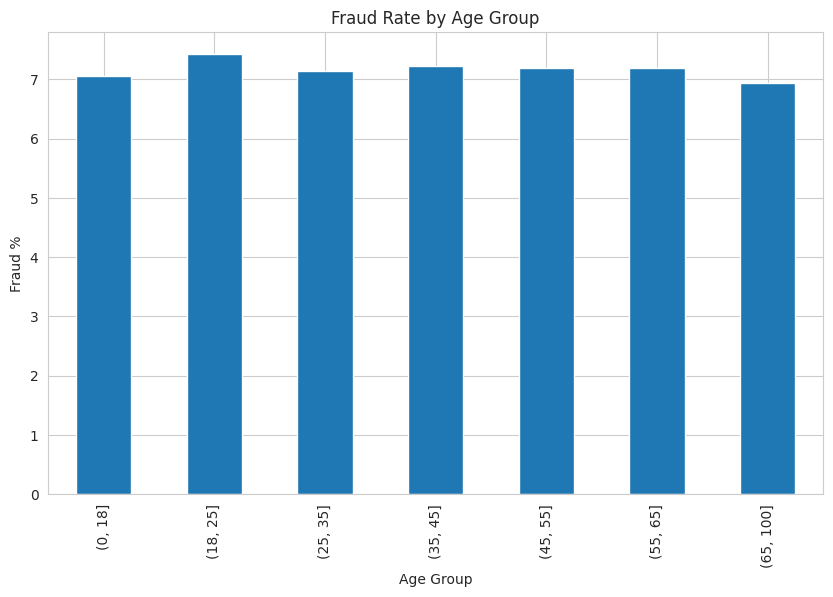

In [992]:
age_fraud = pd.crosstab(
    df['Age Group'],
    df['Fraud'],
    normalize='index'
)*100

age_fraud[1]\
.plot(
    kind='bar'
)

plt.ylabel('Fraud %')

plt.title(
    'Fraud Rate by Age Group'
)

plt.show()

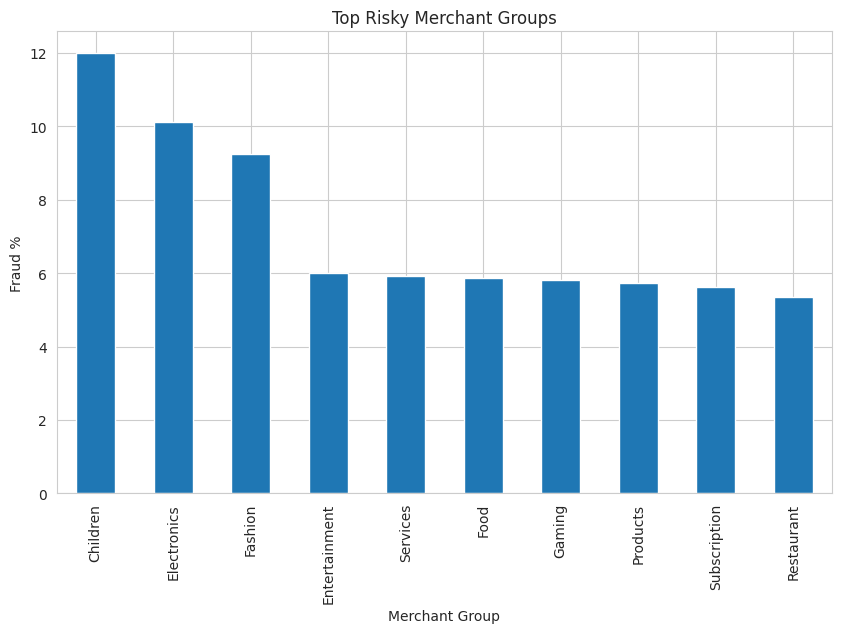

In [993]:
merchant_fraud = pd.crosstab(
    df['Merchant Group'],
    df['Fraud'],
    normalize='index'
)*100

merchant_fraud[1]\
.sort_values(ascending=False)\
.head(10)\
.plot(
    kind='bar'
)

plt.ylabel('Fraud %')

plt.title(
    'Top Risky Merchant Groups'
)

plt.show()

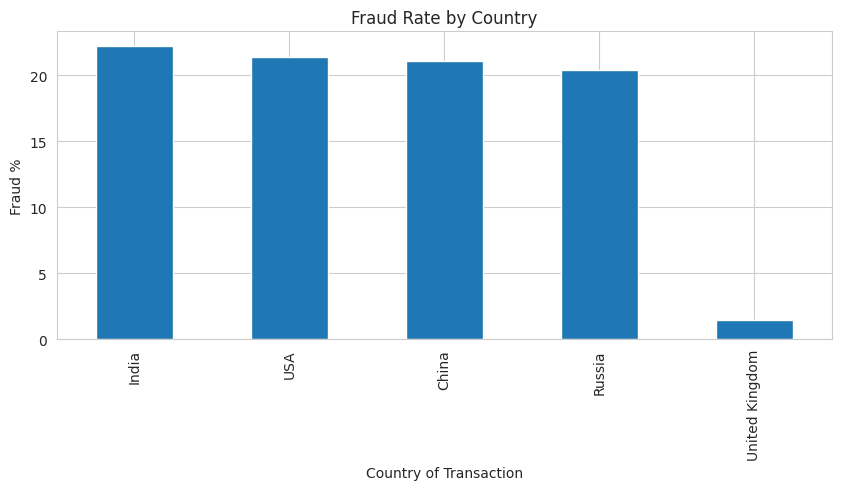

In [994]:
country_fraud = pd.crosstab(
    df['Country of Transaction'],
    df['Fraud'],
    normalize='index'
)*100

country_fraud[1]\
.sort_values(ascending=False)\
.plot(
    kind='bar',
    figsize=(10,4)
)

plt.ylabel('Fraud %')

plt.title(
    'Fraud Rate by Country'
)

plt.show()

FEATURE ENGINEERING
-

0 = Domestic Transaction
1 = Foreign Transaction

In [995]:
df['Foreign_Transaction'] = (
    df['Country of Residence']
    !=
    df['Country of Transaction']
).astype(int)

In [996]:
pd.crosstab(
    df['Foreign_Transaction'],
    df['Fraud'],
    normalize='index'
) * 100

Fraud,0,1
Foreign_Transaction,,
0,98.663533,1.336467
1,43.705441,56.294559


Amount Transformation
-

In [997]:
import numpy as np

df['Amount_Log'] = np.log1p(df['Amount'])

In [998]:
print("Original:", df['Amount'].skew())
print("Log:", df['Amount_Log'].skew())

Original: 0.9293088968838511
Log: 0.144635457595193


AGE GROUP 
-

In [999]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[18,25,35,45,55,65,100],
    labels=[
        '19-25',
        '26-35',
        '36-45',
        '46-55',
        '56-65',
        '65+'
    ]
)

df['Age Group'] = df['Age Group'].astype(str)

TIME BIN
-

In [1000]:
df['Time_Bin'] = pd.cut(
    df['Time'],
    bins=[-1,6,12,18,24],
    labels=[
        'Night',
        'Morning',
        'Afternoon',
        'Evening'
    ]
)

df['Time_Bin'] = df['Time_Bin'].astype(str)

CARD + ENTRY MODE(USEFUL PATTERN)
-

In [1001]:
df['Card_Entry'] = (
    df['Type of Card']
    +
    "_"
    +
    df['Entry Mode']
)

In [1002]:
pd.crosstab(
    df['Card_Entry'],
    df['Fraud'],
    normalize='index'
)*100

Fraud,0,1
Card_Entry,,
MasterCard_CVC,91.232000,8.768000
MasterCard_PIN,96.667828,3.332172
MasterCard_Tap,90.269560,9.730440
Visa_CVC,89.745744,10.254256
Visa_PIN,94.888593,5.111407
Visa_Tap,87.603491,12.396509


In [1003]:
threshold = df['Amount'].quantile(0.75)

df['High_Amount'] = (
    df['Amount'] > threshold
).astype(int)

In [1004]:
new_features = [
    'Foreign_Transaction',
    'Amount_Log',
    'Age Group',
    'Time_Bin',
    'Card_Entry',
    'High_Amount'
]

print(df[new_features].head())

   Foreign_Transaction  Amount_Log Age Group   Time_Bin      Card_Entry  \
0                    0    1.791759     26-35    Evening        Visa_Tap   
1                    0    5.666427     46-55  Afternoon  MasterCard_PIN   
2                    0    1.791759     36-45  Afternoon        Visa_Tap   
3                    0    3.367296     46-55  Afternoon        Visa_Tap   
4                    1    4.521789     36-45    Evening        Visa_CVC   

   High_Amount  
0            0  
1            1  
2            0  
3            0  
4            0  


Train / Validation / Test Split
-
↓
Encoding
-
↓
Logistic Regression
-
↓
Random Forest
-
↓
XGBoost
-
↓
CatBoost
-

In [1005]:
num_cols = df.select_dtypes(
    include=['int64','float64']
).columns

print(num_cols)

Index(['Time', 'Amount', 'Age', 'Fraud', 'Foreign_Transaction', 'Amount_Log',
       'High_Amount'],
      dtype='object')


In [1006]:
num_cols = df.select_dtypes(
    include=['int64','float64']
).columns

In [1007]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Shape: (100000, 21)

Columns:
['Transaction ID', 'Day of Week', 'Time', 'Type of Card', 'Entry Mode', 'Amount', 'Type of Transaction', 'Merchant Group', 'Country of Transaction', 'Shipping Address', 'Country of Residence', 'Gender', 'Age', 'Bank', 'Fraud', 'Age Group', 'Foreign_Transaction', 'Amount_Log', 'Time_Bin', 'Card_Entry', 'High_Amount']

Data Types:
Transaction ID             object
Day of Week                object
Time                        Int64
Type of Card               object
Entry Mode                 object
Amount                    float64
Type of Transaction        object
Merchant Group             object
Country of Transaction     object
Shipping Address           object
Country of Residence       object
Gender                     object
Age                       float64
Bank                       object
Fraud                       int64
Age Group                  object
Foreign_Transaction         int64
Amount_Log                float64
Time_Bin                   

,Transaction ID,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,...,Gender,Age,Bank,Fraud,Age Group,Foreign_Transaction,Amount_Log,Time_Bin,Card_Entry,High_Amount
0,#3577 209,Wednesday,19,Visa,Tap,5.0,POS,Entertainment,United Kingdom,United Kingdom,...,M,25.2,RBS,0,26-35,0,1.791759,Evening,Visa_Tap,0
1,#3039 221,Wednesday,17,MasterCard,PIN,288.0,POS,Services,USA,USA,...,F,49.6,Lloyds,0,46-55,0,5.666427,Afternoon,MasterCard_PIN,1
2,#2694 780,Wednesday,14,Visa,Tap,5.0,POS,Restaurant,India,India,...,F,42.2,Barclays,0,36-45,0,1.791759,Afternoon,Visa_Tap,0
3,#2640 960,Tuesday,14,Visa,Tap,28.0,POS,Entertainment,United Kingdom,India,...,F,51.0,Barclays,0,46-55,0,3.367296,Afternoon,Visa_Tap,0
4,#2771 031,Tuesday,23,Visa,CVC,91.0,Online,Electronics,USA,USA,...,M,38.0,Halifax,1,36-45,1,4.521789,Evening,Visa_CVC,0


In [1008]:
cat_cols = df.select_dtypes(
    include=['object','category']
).columns

print(cat_cols)

Index(['Transaction ID', 'Day of Week', 'Type of Card', 'Entry Mode',
       'Type of Transaction', 'Merchant Group', 'Country of Transaction',
       'Shipping Address', 'Country of Residence', 'Gender', 'Bank',
       'Age Group', 'Time_Bin', 'Card_Entry'],
      dtype='object')


In [1009]:
pd.crosstab(
    df['Type of Card'],
    df['Fraud'],
    normalize='index'
)*100

Fraud,0,1
Type of Card,,
MasterCard,93.775440,6.224560
Visa,91.972051,8.027949


In [1010]:
print(df.columns.tolist())

['Transaction ID', 'Day of Week', 'Time', 'Type of Card', 'Entry Mode', 'Amount', 'Type of Transaction', 'Merchant Group', 'Country of Transaction', 'Shipping Address', 'Country of Residence', 'Gender', 'Age', 'Bank', 'Fraud', 'Age Group', 'Foreign_Transaction', 'Amount_Log', 'Time_Bin', 'Card_Entry', 'High_Amount']


In [1011]:
df.isnull().sum()

Transaction ID            0
Day of Week               0
Time                      0
Type of Card              0
Entry Mode                0
Amount                    0
Type of Transaction       0
Merchant Group            0
Country of Transaction    0
Shipping Address          0
Country of Residence      0
Gender                    0
Age                       0
Bank                      0
Fraud                     0
Age Group                 0
Foreign_Transaction       0
Amount_Log                0
Time_Bin                  0
Card_Entry                0
High_Amount               0
dtype: int64

In [1012]:
df.columns = df.columns.str.strip()

DROPPING TRANSACTION ID AS I NEED TO START TRAINING/ TESTING
-

In [1013]:
if 'Transaction ID' in df.columns:
    df.drop('Transaction ID', axis=1, inplace=True)

print(df.columns.tolist())

['Day of Week', 'Time', 'Type of Card', 'Entry Mode', 'Amount', 'Type of Transaction', 'Merchant Group', 'Country of Transaction', 'Shipping Address', 'Country of Residence', 'Gender', 'Age', 'Bank', 'Fraud', 'Age Group', 'Foreign_Transaction', 'Amount_Log', 'Time_Bin', 'Card_Entry', 'High_Amount']


In [1014]:
X = df.drop('Fraud', axis=1)
y = df['Fraud']

print(df.columns.tolist())

['Day of Week', 'Time', 'Type of Card', 'Entry Mode', 'Amount', 'Type of Transaction', 'Merchant Group', 'Country of Transaction', 'Shipping Address', 'Country of Residence', 'Gender', 'Age', 'Bank', 'Fraud', 'Age Group', 'Foreign_Transaction', 'Amount_Log', 'Time_Bin', 'Card_Entry', 'High_Amount']


TRAIN-TEST-VALIDATE SPLIT
-

In [1015]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(60000, 19)
(20000, 19)
(20000, 19)


In [1016]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(60000, 19)
(20000, 19)
(20000, 19)


In [1017]:
print(X_train.dtypes)

Day of Week                object
Time                        Int64
Type of Card               object
Entry Mode                 object
Amount                    float64
Type of Transaction        object
Merchant Group             object
Country of Transaction     object
Shipping Address           object
Country of Residence       object
Gender                     object
Age                       float64
Bank                       object
Age Group                  object
Foreign_Transaction         int64
Amount_Log                float64
Time_Bin                   object
Card_Entry                 object
High_Amount                 int64
dtype: object


PERFORMING ENCODING
-

In [1018]:
cat_cols = X_train.select_dtypes(
    include=['object']
).columns

print(cat_cols)

Index(['Day of Week', 'Type of Card', 'Entry Mode', 'Type of Transaction',
       'Merchant Group', 'Country of Transaction', 'Shipping Address',
       'Country of Residence', 'Gender', 'Bank', 'Age Group', 'Time_Bin',
       'Card_Entry'],
      dtype='object')


In [1019]:
print(
    X_train.select_dtypes(
        include=['category']
    ).columns
)

Index([], dtype='object')


APPLYING ORDINAL ENCODING(IT WORKS BETTER IN THIS DATASET)
-

In [1021]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

FIT ONLY TEST
-

In [1022]:
X_train[cat_cols] = encoder.fit_transform(
    X_train[cat_cols]
)

TRANSFORMATION VALIDATE
-

In [1023]:
X_val[cat_cols] = encoder.transform(
    X_val[cat_cols]
)

In [1024]:
X_test[cat_cols] = encoder.transform(
    X_test[cat_cols]
)

In [1025]:
print(X_train.dtypes.value_counts())

float64    16
int64       2
Int64       1
Name: count, dtype: int64


In [1026]:
print(X_train.isnull().sum().sum())
print(X_val.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0
0


In [1027]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[cat_cols] = encoder.fit_transform(
    X_train[cat_cols]
)

X_val[cat_cols] = encoder.transform(
    X_val[cat_cols]
)

X_test[cat_cols] = encoder.transform(
    X_test[cat_cols]
)

In [1028]:
print(
    X_train.dtypes.value_counts()
)

float64    16
int64       2
Int64       1
Name: count, dtype: int64


CREATING COPY DATASET FOR LOG VALUE OF AMOUNT
-

In [1029]:
X_train_amt = X_train.copy()
X_val_amt = X_val.copy()
X_test_amt = X_test.copy()

In [1030]:
X_train_log = X_train.copy()
X_val_log = X_val.copy()
X_test_log = X_test.copy()

X_train_log['Amount'] = np.log1p(
    X_train_log['Amount']
)

X_val_log['Amount'] = np.log1p(
    X_val_log['Amount']
)

X_test_log['Amount'] = np.log1p(
    X_test_log['Amount']
)

In [1031]:
num_cols = X_train.select_dtypes(
    include=['int64','float64']
).columns

print(num_cols)

Index(['Day of Week', 'Time', 'Type of Card', 'Entry Mode', 'Amount',
       'Type of Transaction', 'Merchant Group', 'Country of Transaction',
       'Shipping Address', 'Country of Residence', 'Gender', 'Age', 'Bank',
       'Age Group', 'Foreign_Transaction', 'Amount_Log', 'Time_Bin',
       'Card_Entry', 'High_Amount'],
      dtype='object')


In [1032]:
from sklearn.preprocessing import StandardScaler

scaler1 = StandardScaler()

X_train_amt[num_cols] = scaler1.fit_transform(
    X_train_amt[num_cols]
)

X_val_amt[num_cols] = scaler1.transform(
    X_val_amt[num_cols]
)

X_test_amt[num_cols] = scaler1.transform(
    X_test_amt[num_cols]
)

In [1034]:
scaler2 = StandardScaler()

X_train_log[num_cols] = scaler2.fit_transform(
    X_train_log[num_cols]
)

X_val_log[num_cols] = scaler2.transform(
    X_val_log[num_cols]
)

X_test_log[num_cols] = scaler2.transform(
    X_test_log[num_cols]
)

TRAINING LOGISTIC-REGRESSION
-

In [1035]:
from sklearn.linear_model import LogisticRegression

lr_amt = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_amt.fit(
    X_train_amt,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [1036]:
y_pred_amt = lr_amt.predict(
    X_val_amt
)

y_prob_amt = lr_amt.predict_proba(
    X_val_amt
)[:,1]

ROC-AUC VALUE
-

In [1037]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:",
      accuracy_score(y_val,y_pred_amt))

print("Precision:",
      precision_score(y_val,y_pred_amt))

print("Recall:",
      recall_score(y_val,y_pred_amt))

print("F1:",
      f1_score(y_val,y_pred_amt))

print("ROC-AUC:",
      roc_auc_score(y_val,y_prob_amt))

Accuracy: 0.9294
Precision: 0.5051078320090806
Recall: 0.9277275886031967
F1: 0.6540911317981382
ROC-AUC: 0.9767729409693163


TRAINING LOGISTIC-REGRESSION FOR AMOUNT LOG VALUE
-

In [1038]:
lr_log = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_log.fit(
    X_train_log,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [1039]:
y_pred_log = lr_log.predict(
    X_val_log
)

y_prob_log = lr_log.predict_proba(
    X_val_log
)[:,1]

In [1040]:
auc_log = roc_auc_score(
    y_val,
    y_prob_log
)

print("Accuracy:",
      accuracy_score(y_val,y_pred_log))

print("Precision:",
      precision_score(y_val,y_pred_log))

print("Recall:",
      recall_score(y_val,y_pred_log))

print("F1:",
      f1_score(y_val,y_pred_log))

print("ROC-AUC:",
      auc_log)

Accuracy: 0.93
Precision: 0.5074285714285715
Recall: 0.925642807505212
F1: 0.655511811023622
ROC-AUC: 0.9767760859437652


In [1041]:
comparison = pd.DataFrame({

    'Version':[
        'Original Amount',
        'Log Amount'
    ],

    'ROC_AUC':[

        roc_auc_score(
            y_val,
            y_prob_amt
        ),

        roc_auc_score(
            y_val,
            y_prob_log
        )
    ]
})

print(comparison)

           Version   ROC_AUC
0  Original Amount  0.976773
1       Log Amount  0.976776


RANDOM FOREST 
-

NORMAL AMOUNT VALUE
-

In [1042]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

y_prob_rf = rf.predict_proba(
    X_val
)[:,1]

rf_auc = roc_auc_score(
    y_val,
    y_prob_rf
)

print(
    "Validation ROC-AUC:",
    rf_auc
)

Validation ROC-AUC: 0.992590252997844


In [1043]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

y_prob_rf = rf.predict_proba(
     X_val
 )[:,1]

rf_auc = roc_auc_score(
     y_val,
     y_prob_rf
 )
print(
      "Validate ROC-AUC:",
     rf_auc
 )

Validate ROC-AUC: 0.992590252997844


In [1044]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred_rf = rf.predict(X_val)
y_prob_rf = rf.predict_proba(X_val)[:,1]

acc_rf = accuracy_score(y_val, y_pred_rf)
prec_rf = precision_score(y_val, y_pred_rf)
rec_rf = recall_score(y_val, y_pred_rf)
f1_rf = f1_score(y_val, y_pred_rf)
auc_rf = roc_auc_score(y_val, y_prob_rf)

print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)
print("F1:", f1_rf)
print("ROC-AUC:", auc_rf)

Accuracy: 0.9514
Precision: 0.6049438202247192
Recall: 0.935371785962474
F1: 0.7347161572052402
ROC-AUC: 0.992590252997844


FOR LOG AMOUNT VALUE
-

In [1045]:
rf_log = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_log.fit(
    X_train_log,
    y_train
)

y_prob_rf_log = rf_log.predict_proba(
    X_val_log
)[:,1]

rf_log_auc = roc_auc_score(
    y_val,
    y_prob_rf_log
)

print(
    "Validation ROC-AUC (Log Amount):",
    rf_log_auc
)

Validation ROC-AUC (Log Amount): 0.9925886056302755


In [1046]:
y_pred_rf_log = rf_log.predict(X_val_log)
y_prob_rf_log = rf_log.predict_proba(X_val_log)[:,1]

acc_rf_log = accuracy_score(y_val, y_pred_rf_log)
prec_rf_log = precision_score(y_val, y_pred_rf_log)
rec_rf_log = recall_score(y_val, y_pred_rf_log)
f1_rf_log = f1_score(y_val, y_pred_rf_log)
auc_rf_log = roc_auc_score(y_val, y_prob_rf_log)

print("Accuracy:", acc_rf_log)
print("Precision:", prec_rf_log)
print("Recall:", rec_rf_log)
print("F1:", f1_rf_log)
print("ROC-AUC:", auc_rf_log)

Accuracy: 0.95145
Precision: 0.6052158273381295
Recall: 0.935371785962474
F1: 0.7349167349167349
ROC-AUC: 0.9925886056302755


XGBOOST MODEL 
-

NORMAL AMOUNT VALUE
-

In [1047]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train,
    y_train
)

y_prob_xgb = xgb.predict_proba(
    X_val
)[:,1]

xgb_auc = roc_auc_score(
    y_val,
    y_prob_xgb
)

print(
    "Validation ROC-AUC:",
    xgb_auc
)

Validation ROC-AUC: 0.9932868648382459


XGBOOST METRICES
-

In [1048]:
y_pred_xgb = xgb.predict(X_val)
y_prob_xgb = xgb.predict_proba(X_val)[:,1]

acc_xgb = accuracy_score(y_val, y_pred_xgb)
prec_xgb = precision_score(y_val, y_pred_xgb)
rec_xgb = recall_score(y_val, y_pred_xgb)
f1_xgb = f1_score(y_val, y_pred_xgb)
auc_xgb = roc_auc_score(y_val, y_prob_xgb)

print("Accuracy:", acc_xgb)
print("Precision:", prec_xgb)
print("Recall:", rec_xgb)
print("F1:", f1_xgb)
print("ROC-AUC:", auc_xgb)

Accuracy: 0.9861
Precision: 0.9603489294210944
Recall: 0.8415566365531619
F1: 0.8970370370370371
ROC-AUC: 0.9932868648382459


XGBOOST LOG AMOUNT
-

In [1049]:
xgb_log = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_log.fit(
    X_train_log,
    y_train
)

y_prob_xgb_log = xgb_log.predict_proba(
    X_val_log
)[:,1]

xgb_log_auc = roc_auc_score(
    y_val,
    y_prob_xgb_log
)

print(
    "Validation ROC-AUC (Log Amount):",
    xgb_log_auc
)

Validation ROC-AUC (Log Amount): 0.9932868648382459


In [1050]:
y_pred_xgb_log = xgb_log.predict(X_val_log)
y_prob_xgb_log = xgb_log.predict_proba(X_val_log)[:,1]

acc_xgb_log = accuracy_score(y_val, y_pred_xgb_log)
prec_xgb_log = precision_score(y_val, y_pred_xgb_log)
rec_xgb_log = recall_score(y_val, y_pred_xgb_log)
f1_xgb_log = f1_score(y_val, y_pred_xgb_log)
auc_xgb_log = roc_auc_score(y_val, y_prob_xgb_log)

print("Accuracy:", acc_xgb_log)
print("Precision:", prec_xgb_log)
print("Recall:", rec_xgb_log)
print("F1:", f1_xgb_log)
print("ROC-AUC:", auc_xgb_log)

Accuracy: 0.9861
Precision: 0.9603489294210944
Recall: 0.8415566365531619
F1: 0.8970370370370371
ROC-AUC: 0.9932868648382459


In [1051]:
x_pred_xgb_log = xgb_log.predict(X_val_log)
y_prob_xgb_log = xgb_log.predict_proba(X_val_log)[:,1]

acc_xgb_log = accuracy_score(y_val, y_pred_xgb_log)
prec_xgb_log = precision_score(y_val,y_pred_xgb_log)
rec_xgb_log = recall_score(y_val, y_pred_xgb_log)
f1_xgb_log = f1_score(y_val, y_pred_xgb_log)
auc_xgb_log = roc_auc_score(y_val, y_prob_xgb_log)


print("Accuracy:", acc_xgb_log)
print("Precision:", prec_xgb_log)
print("Recall:", rec_xgb_log)
print("F1:", f1_xgb_log)
print("ROC-AUC:", auc_xgb_log)

Accuracy: 0.9861
Precision: 0.9603489294210944
Recall: 0.8415566365531619
F1: 0.8970370370370371
ROC-AUC: 0.9932868648382459


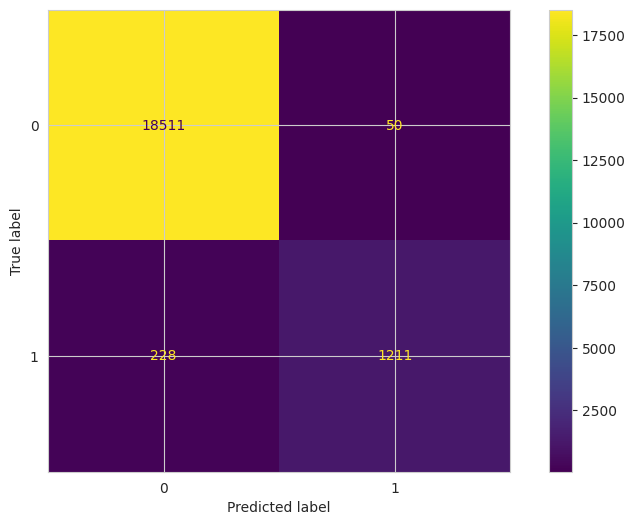

In [1052]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_xgb
)

CATBOOST MODEL
-

NORMAL AMOUNT DATA
-

In [1053]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0
)

cat.fit(
    X_train,
    y_train
)

y_prob_cat = cat.predict_proba(
    X_val
)[:,1]

cat_auc = roc_auc_score(
    y_val,
    y_prob_cat
)

print(
    "Validation ROC-AUC:",
    cat_auc
)

Validation ROC-AUC: 0.9936850785077351


PERFORMING ONE-HOT-ENCODING TO COMPARE THE RESULT
-

X_train, X_val, X_test
y_train, y_val, y_test

In [1054]:
import pandas as pd
import numpy as np

df['Time_Bin'] = pd.cut(
    df['Time'],
    bins=[-1, 5, 11, 17, 23],
    labels=[
        'Night',
        'Morning',
        'Afternoon',
        'Evening'
    ]
)

In [1055]:
df = df.dropna(subset=['Time_Bin'])

In [1056]:
df.drop('Time', axis=1, inplace=True)

In [1057]:
X = df.drop('Fraud', axis=1)
y = df['Fraud']

In [1058]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(59999, 18)
(20000, 18)
(20000, 18)


In [1059]:
cat_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns

print(cat_cols)

Index(['Day of Week', 'Type of Card', 'Entry Mode', 'Type of Transaction',
       'Merchant Group', 'Country of Transaction', 'Shipping Address',
       'Country of Residence', 'Gender', 'Bank', 'Age Group', 'Time_Bin',
       'Card_Entry'],
      dtype='object')


In [1060]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(

    transformers=[

        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            cat_cols
        )

    ],

    remainder='passthrough'

)

In [1061]:
X_train_ohe = preprocessor.fit_transform(X_train)

X_val_ohe = preprocessor.transform(X_val)

X_test_ohe = preprocessor.transform(X_test)

In [1062]:
feature_names = preprocessor.get_feature_names_out()

In [1063]:
X_train_ohe_df = pd.DataFrame(
    X_train_ohe.toarray(),
    columns=feature_names,
    index=X_train.index
)

X_val_ohe_df = pd.DataFrame(
    X_val_ohe.toarray(),
    columns=feature_names,
    index=X_val.index
)

X_test_ohe_df = pd.DataFrame(
    X_test_ohe.toarray(),
    columns=feature_names,
    index=X_test.index
)

In [1064]:
print(X_train_ohe_df.head())

       cat__Day of Week_Thursday  cat__Day of Week_Tuesday  \
41069                        0.0                       0.0   
700                          0.0                       0.0   
84543                        0.0                       0.0   
19830                        0.0                       1.0   
78664                        0.0                       1.0   

       cat__Day of Week_Wednesday  cat__Type of Card_Visa  \
41069                         1.0                     0.0   
700                           1.0                     1.0   
84543                         1.0                     0.0   
19830                         0.0                     0.0   
78664                         0.0                     1.0   

       cat__Entry Mode_PIN  cat__Entry Mode_Tap  \
41069                  1.0                  0.0   
700                    1.0                  0.0   
84543                  1.0                  0.0   
19830                  1.0                  0.0   
78664

In [894]:
print(X_train_ohe_df.tail())

       cat__Day of Week_Thursday  cat__Day of Week_Tuesday  \
7637                         0.0                       1.0   
59962                        0.0                       1.0   
40216                        0.0                       1.0   
40477                        0.0                       0.0   
27318                        0.0                       1.0   

       cat__Day of Week_Wednesday  cat__Type of Card_Visa  \
7637                          0.0                     1.0   
59962                         0.0                     1.0   
40216                         0.0                     0.0   
40477                         1.0                     1.0   
27318                         0.0                     1.0   

       cat__Entry Mode_PIN  cat__Entry Mode_Tap  \
7637                   1.0                  0.0   
59962                  1.0                  0.0   
40216                  0.0                  0.0   
40477                  1.0                  0.0   
27318

In [1065]:
time_cols = [
    col for col in X_train_ohe_df.columns
    if 'Time_Bin' in col
]

X_train_ohe_df[time_cols].head()

,cat__Time_Bin_Evening,cat__Time_Bin_Morning,cat__Time_Bin_Night
41069,1.0,0.0,0.0
700,0.0,0.0,1.0
84543,0.0,1.0,0.0
19830,1.0,0.0,0.0
78664,0.0,0.0,0.0


LOGISTIC REGRESSION
-

In [1066]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_ohe_df,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

LOGISTIC REGRESSION METRICS
-

In [1067]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = lr.predict(X_val_ohe_df)

y_prob = lr.predict_proba(
    X_val_ohe_df
)[:,1]

acc_lr = accuracy_score(y_val, y_pred)
prec_lr = precision_score(y_val, y_pred)
rec_lr = recall_score(y_val, y_pred)
f1_lr = f1_score(y_val, y_pred)
auc_lr = roc_auc_score(y_val, y_prob)

print("Accuracy:", acc_lr)
print("Precision:", prec_lr)
print("Recall:", rec_lr)
print("F1:", f1_lr)
print("ROC-AUC:", auc_lr)

Accuracy: 0.94025
Precision: 0.5492332526230831
Recall: 0.9457956914523975
F1: 0.6949195813122288
ROC-AUC: 0.985652252163003


CONFUSION MATRICS
-

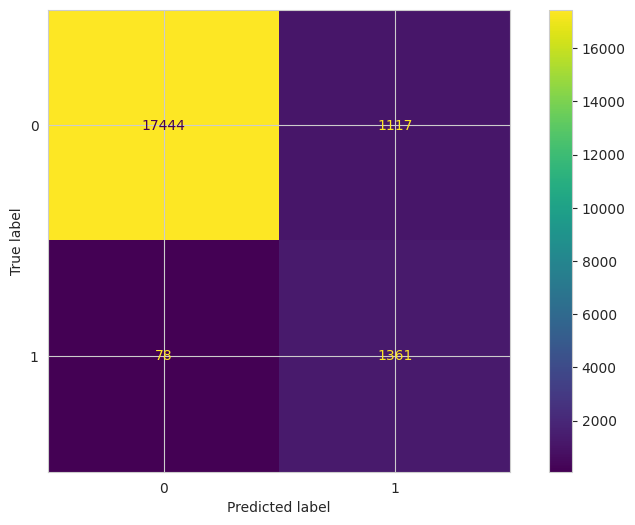

In [1068]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred
)

RANDOMFOREST MODEL
-

In [1069]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_ohe_df,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       n_jobs=-1, random_state=42)

RANDOMFOREST METRICS
-

In [1070]:
y_pred_rf = rf.predict(X_val_ohe_df)

y_prob_rf = rf.predict_proba(
    X_val_ohe_df
)[:,1]

acc_rf = accuracy_score(y_val, y_pred_rf)
prec_rf = precision_score(y_val, y_pred_rf)
rec_rf = recall_score(y_val, y_pred_rf)
f1_rf = f1_score(y_val, y_pred_rf)
auc_rf = roc_auc_score(y_val, y_prob_rf)

print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)
print("F1:", f1_rf)
print("ROC-AUC:", auc_rf)

Accuracy: 0.93725
Precision: 0.5361351139041634
Recall: 0.9485753995830438
F1: 0.685069008782936
ROC-AUC: 0.9896568529611001


CONFUISON MATRICS
-

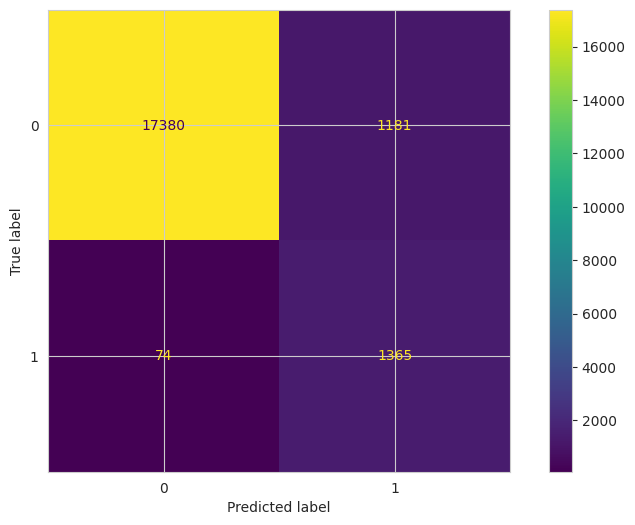

In [1071]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_rf
)

XGBOOST CLASSIFIER
-

In [1072]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train_ohe_df,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [1073]:
y_pred_xgb = xgb.predict(X_val_ohe_df)

y_prob_xgb = xgb.predict_proba(
    X_val_ohe_df
)[:,1]

acc_xgb = accuracy_score(y_val, y_pred_xgb)
prec_xgb = precision_score(y_val, y_pred_xgb)
rec_xgb = recall_score(y_val, y_pred_xgb)
f1_xgb = f1_score(y_val, y_pred_xgb)
auc_xgb = roc_auc_score(y_val, y_prob_xgb)

print("Accuracy:", acc_xgb)
print("Precision:", prec_xgb)
print("Recall:", rec_xgb)
print("F1:", f1_xgb)
print("ROC-AUC:", auc_xgb)

Accuracy: 0.98445
Precision: 0.9519230769230769
Recall: 0.8255733148019458
F1: 0.8842575362858206
ROC-AUC: 0.9928395671032528


In [1074]:
from sklearn.metrics import roc_auc_score

train_prob = xgb.predict_proba(
    X_train_ohe_df
)[:,1]

train_auc = roc_auc_score(
    y_train,
    train_prob
)

print("Train ROC-AUC:", train_auc)

Train ROC-AUC: 0.9991659975389949


In [1075]:
val_prob = xgb.predict_proba(
    X_val_ohe_df
)[:,1]

val_auc = roc_auc_score(
    y_val,
    val_prob
)

print("Validation ROC-AUC:", val_auc)

Validation ROC-AUC: 0.9928395671032528


In [1076]:
print("Train ROC-AUC:", train_auc)
print("Validation ROC-AUC:", val_auc)
print("Difference:", train_auc - val_auc)

Train ROC-AUC: 0.9991659975389949
Validation ROC-AUC: 0.9928395671032528
Difference: 0.006326430435742103


In [1077]:
from sklearn.metrics import accuracy_score

train_pred = xgb.predict(X_train_ohe_df)
val_pred = xgb.predict(X_val_ohe_df)

train_acc = accuracy_score(
    y_train,
    train_pred
)

val_acc = accuracy_score(
    y_val,
    val_pred
)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

Train Accuracy: 0.9909831830530509
Validation Accuracy: 0.98445


CONFUSION MATRICS
-

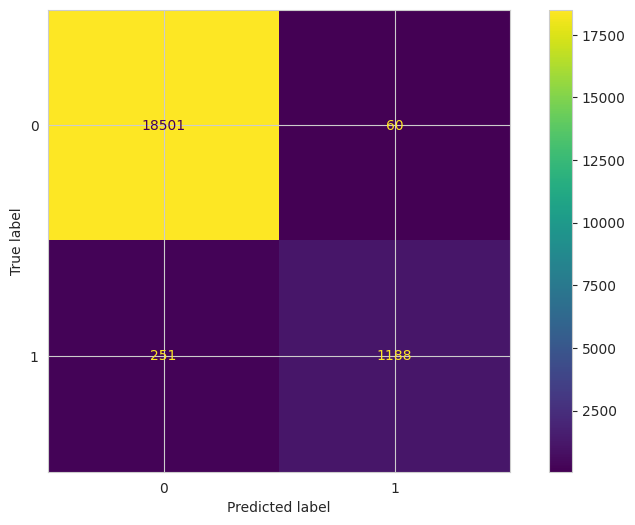

In [1078]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_xgb
)

SHAP ANALYSIS
-

In [1079]:
!pip install shap -q

In [1080]:
import shap

In [1081]:
explainer = shap.TreeExplainer(
    xgb
)

In [1083]:
sample = X_val_ohe_df.sample(
    1000,
    random_state=42
)

In [1084]:
shap_values = explainer.shap_values(
    sample
)

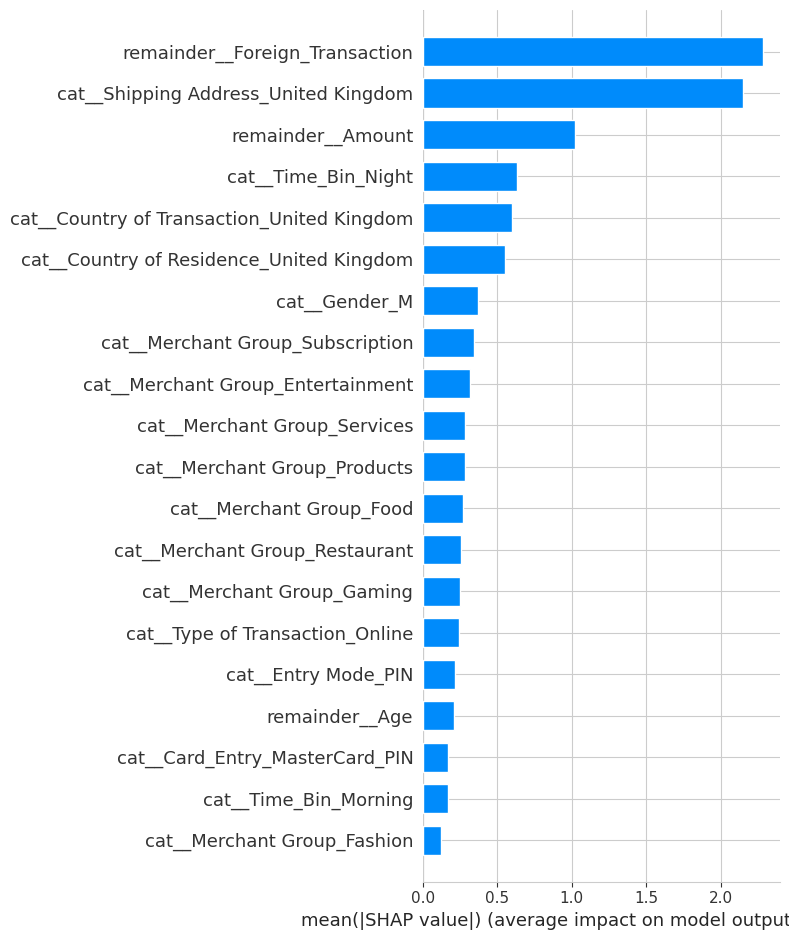

In [1085]:
shap.summary_plot(
    shap_values,
    sample,
    plot_type='bar'
)

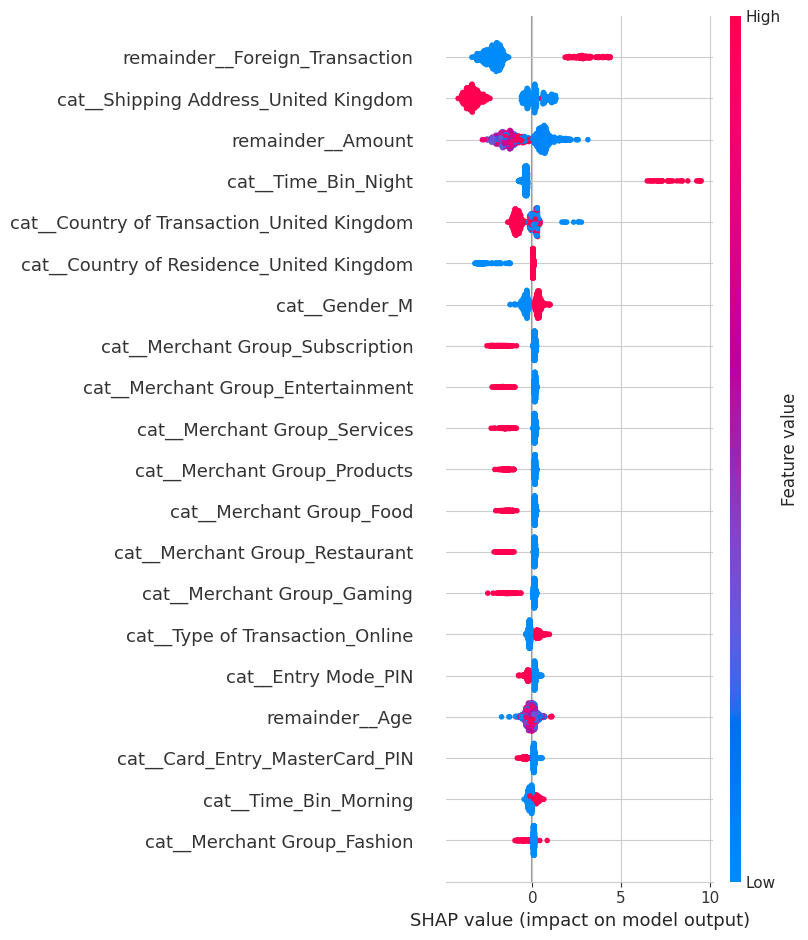

In [1086]:
shap.summary_plot(
    shap_values,
    sample
)

Top 20 Feature Table
-

In [1087]:
import pandas as pd
import numpy as np

importance = pd.DataFrame({
    'Feature': sample.columns,
    'SHAP Importance':
        np.abs(shap_values).mean(axis=0)
})

importance = importance.sort_values(
    'SHAP Importance',
    ascending=False
)

importance.head(20)

,Feature,SHAP Importance
56,remainder__Foreign_Transaction,2.285178
25,cat__Shipping Address_United Kingdom,2.152874
54,remainder__Amount,1.023241
48,cat__Time_Bin_Night,0.633986
21,cat__Country of Transaction_United Kingdom,0.596620
30,cat__Country of Residence_United Kingdom,0.552272
31,cat__Gender_M,0.365988
16,cat__Merchant Group_Subscription,0.345176
9,cat__Merchant Group_Entertainment,0.312974
15,cat__Merchant Group_Services,0.281406


LOGISTIC REGRESSION
-

CHECKING OVERFITING
-

RANDOM FOREST
-

CHECK FOR OVERFITTING
-

XGBOOST MODEL
-

CHECKING OVERFITTING
-

CATBOOST MODEL
-

PERFORMING SHAP
-

In [707]:
import shap

In [708]:
xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [709]:
explainer = shap.TreeExplainer(xgb)

In [710]:
xgb_ohe

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)


-


-